In [1]:
import pandas as pd

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [3]:
df = df.drop('customerID', axis=1)

In [4]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

## Feature Engineering
Binary text columns (e.g. Partner, Churn) → Label Encoded.
Multi-category columns (e.g. Contract, InternetService, PaymentMethod) → 
One-Hot Encoded to avoid implying false ordinal relationships.

In [5]:
for col in df.select_dtypes(include='object').columns:
    print(col, '->', df[col].nunique(), 'unique values:', df[col].unique())

gender -> 2 unique values: ['Female' 'Male']
Partner -> 2 unique values: ['Yes' 'No']
Dependents -> 2 unique values: ['No' 'Yes']
PhoneService -> 2 unique values: ['No' 'Yes']
MultipleLines -> 3 unique values: ['No phone service' 'No' 'Yes']
InternetService -> 3 unique values: ['DSL' 'Fiber optic' 'No']
OnlineSecurity -> 3 unique values: ['No' 'Yes' 'No internet service']
OnlineBackup -> 3 unique values: ['Yes' 'No' 'No internet service']
DeviceProtection -> 3 unique values: ['No' 'Yes' 'No internet service']
TechSupport -> 3 unique values: ['No' 'Yes' 'No internet service']
StreamingTV -> 3 unique values: ['No' 'Yes' 'No internet service']
StreamingMovies -> 3 unique values: ['No' 'Yes' 'No internet service']
Contract -> 3 unique values: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling -> 2 unique values: ['Yes' 'No']
PaymentMethod -> 4 unique values: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn -> 2 unique values: ['No' 'Ye

In [6]:
# Label Encode the Binary 
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

In [7]:
df[binary_cols].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,0,1,0,0,1,0
1,1,0,0,1,0,0
2,1,0,0,1,1,1
3,1,0,0,0,0,0
4,0,0,0,1,1,1


In [8]:
#One-Hot Encode the multi-category columns
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
              'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)


In [9]:
df.shape
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [10]:
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})

In [11]:
df.dtypes.value_counts()

int64      29
float64     2
Name: count, dtype: int64

In [12]:
df.shape

(7043, 31)

All features converted to numeric (29 int64 + 2 float64 columns). Dataset 
ready for modeling.

In [13]:
#Seperate feature(x) from target(y)
X = df.drop('Churn', axis=1)
y = df['Churn']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(5634, 30) (1409, 30)
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [16]:
from sklearn.linear_model import LogisticRegression

# training the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

C:\ML\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [17]:
# Make predictions 
y_pred= model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score

#accuracy check
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8041


In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[925 110]
 [166 208]]


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



## Baseline Model — Logistic Regression
Accuracy: 80%, but recall on churn is only 56% — missing 44% of actual 
churners. Recall matters more than accuracy here, since missing a real 
churner is costlier than a false alarm.

Next:Try `class_weight='balanced'` before moving to Random Forest/XGBoost.

In [21]:
# Retrain model
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



C:\ML\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Balanced Model — Trade-off Analysis
`class_weight='balanced'` raised recall on churn from 56% to 79%, but 
precision dropped from 65% to 50% and accuracy from 80% to 74%. Recall is 
prioritized here since acquiring a new customer typically costs more than 
retaining one — missing a churner is costlier than a false alarm.

## Random Forest

In [22]:
from sklearn.ensemble import RandomForestClassifier

# 100 trees, balanced weights to handle class imbalance
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

[[932 103]
 [191 183]]


## Model Comparison
| Model | Precision | Recall | F1 | Accuracy |
|---|---|---|---|---|
| Logistic Regression (baseline) | 0.65 | 0.56 | 0.60 | 80% |
| Logistic Regression (balanced) | 0.50 | 0.79 | 0.62 | 74% |
| Random Forest (balanced) | 0.64 | 0.49 | 0.55 | 79% |

Random Forest underperformed on recall (49%) despite being the more complex 
model — its majority-voting mechanism dampens class weighting, pulling 
predictions back toward the majority class. Balanced Logistic Regression 
is the best fit here, catching 79% of actual churners.

## Feature Importance

In [23]:
import numpy as np

# Coefficients from the balanced Logistic Regression (our chosen model)
coefs = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model_balanced.coef_[0]
}).sort_values('coefficient', ascending=False)

print("Top 10 features increasing churn risk:")
print(coefs.head(10))

print("\nTop 10 features decreasing churn risk:")
print(coefs.tail(10))

Top 10 features increasing churn risk:
                           feature  coefficient
11     InternetService_Fiber optic     0.457559
9   MultipleLines_No phone service     0.443611
28  PaymentMethod_Electronic check     0.406011
6                 PaperlessBilling     0.340987
10               MultipleLines_Yes     0.174387
1                    SeniorCitizen     0.154856
24             StreamingMovies_Yes     0.117124
22                 StreamingTV_Yes     0.090537
29      PaymentMethod_Mailed check     0.058862
0                           gender     0.029859

Top 10 features decreasing churn risk:
                               feature  coefficient
13  OnlineSecurity_No internet service    -0.072639
12                  InternetService_No    -0.072639
18                DeviceProtection_Yes    -0.112966
16                    OnlineBackup_Yes    -0.225129
3                           Dependents    -0.228672
5                         PhoneService    -0.333238
20                     TechSu

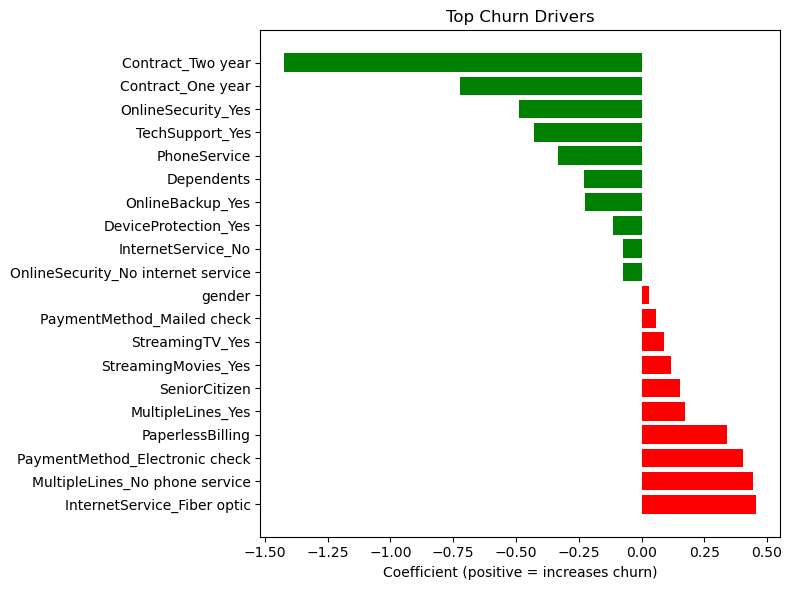

In [24]:
import matplotlib.pyplot as plt

top_features = pd.concat([coefs.head(10), coefs.tail(10)])

plt.figure(figsize=(8,6))
plt.barh(top_features['feature'], top_features['coefficient'], 
         color=['red' if c > 0 else 'green' for c in top_features['coefficient']])
plt.xlabel('Coefficient (positive = increases churn)')
plt.title('Top Churn Drivers')
plt.tight_layout()
plt.show()

## Feature Importance
Two-year contracts are the strongest predictor of retention (coef -1.42), 
nearly 3x stronger than the top churn driver — confirming the contract 
pattern found in EDA. Fiber optic internet (+0.46) and electronic check 
payments (+0.41) are the strongest churn drivers. Support add-ons 
(OnlineSecurity, TechSupport) also significantly reduce churn, suggesting 
bundling them could improve retention.

## Export Predictions for Dashboard

In [25]:
# Predict churn probability (not just yes/no) for the test set
churn_prob = model_balanced.predict_proba(X_test)[:, 1]

# Build output table
predictions = X_test.copy()
predictions['actual_churn'] = y_test
predictions['predicted_churn'] = y_pred_balanced
predictions['churn_probability'] = churn_prob

# Assign risk bands for dashboard segmentation
predictions['risk_band'] = pd.cut(
    churn_prob,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

predictions.to_csv('../data/churn_predictions.csv', index=False)
predictions[['churn_probability', 'risk_band', 'actual_churn']].head(10)

,churn_probability,risk_band,actual_churn
437,0.115568,Low,0
2280,0.851868,High,0
2235,0.161979,Low,0
4460,0.643879,High,0
3761,0.056278,Low,0
5748,0.804321,High,0
3568,0.688962,High,0
2976,0.285179,Low,0
5928,0.008786,Low,0
1639,0.652858,High,1


In [26]:
predictions['risk_band'].value_counts()

risk_band
Low       605
High      488
Medium    316
Name: count, dtype: int64

## Export Predictions for Dashboard
Churn probabilities exported with risk bands (Low/Medium/High) for dashboard 
segmentation. 488 customers flagged High risk vs 374 actual churners — the 
model over-flags by design, prioritizing catching real churners over avoiding 
false alarms.

In [27]:
import os
print(os.listdir('../data'))

['churn_predictions.csv', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [28]:
print(X_train.shape, X_test.shape)
print(y_test.value_counts(normalize=True).round(4))
print(X_test.index[:5].tolist())

(5634, 30) (1409, 30)
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64
[437, 2280, 2235, 4460, 3761]


In [29]:
!pip install xgboost

In [30]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=2.8,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.86      0.79      0.82      1035
           1       0.52      0.64      0.58       374

    accuracy                           0.75      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.77      0.75      0.76      1409

[[816 219]
 [133 241]]


In [31]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'xgb_importance': xgb.feature_importances_
}).sort_values('xgb_importance', ascending=False)

print(importance.head(10))

                           feature  xgb_importance
26               Contract_Two year        0.337802
11     InternetService_Fiber optic        0.187135
25               Contract_One year        0.142637
12              InternetService_No        0.085536
24             StreamingMovies_Yes        0.033612
5                     PhoneService        0.018977
4                           tenure        0.017731
28  PaymentMethod_Electronic check        0.016120
14              OnlineSecurity_Yes        0.012628
8                     TotalCharges        0.012226


In [32]:
import pickle

with open('../model.pkl', 'wb') as f:
    pickle.dump(model_balanced, f)

with open('../columns.pkl', 'wb') as f:
    pickle.dump(list(X_train.columns), f)

print("saved")

saved


In [33]:
import os
print([f for f in os.listdir('..') if f.endswith('.pkl')])

['columns.pkl', 'model.pkl']


In [34]:
!pip install streamlit